In [1]:
import zipfile
import os
from glob import glob
import random
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from google.colab import drive

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# Paths / device

In [2]:
# Define device-agnostic code for flexibility
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

drive.mount('/content/drive',force_remount=True)
%cd /content/drive/MyDrive/UPF_Deep_Learning_2026/final_project

metadata_csv = "data/HAM10000_metadata.csv"

Mounted at /content/drive
/content/drive/MyDrive/UPF_Deep_Learning_2026/final_project


# Load images and preprocessing

In [3]:
df = pd.read_csv(metadata_csv)

destination_folder = Path("images/imatges_ham10000")

if not destination_folder.exists():
  zip_files = Path(['images/HAM10000_images_part_1.zip', 'images/HAM10000_images_part_2.zip'])

  os.makedirs(destination_folder, exist_ok=True)

  print("Extracting and downloading dataset...")

  for f in zip_files:
    with zipfile.ZipFile(f, 'r') as zip_ref:
      zip_ref.extractall(destination_folder)
else:
  print("Dataset already downloaded and extracted")


image_paths = {os.path.splitext(os.path.basename(x))[0]: x
                 for x in glob(os.path.join(destination_folder, '*.jpg'))}

df['path'] = df['image_id'].map(image_paths)
df = df.dropna(subset=['path'])

Dataset already downloaded and extracted


We substract corrupted images:

In [4]:
# print("Verify images...")
# valid_mask = []
# for path in df['path']:
#     try:
#         Image.open(path).verify()

#     except Exception:
#         print(path)

In [5]:
# corrupt_images = [
#     'images/imatges_ham10000/ISIC_0024332.jpg',
#     'images/imatges_ham10000/ISIC_0025870.jpg'
# ]
# df = df[~df['path'].isin(corrupt_images)].reset_index(drop=True)

# Data split

Train: 80% |
Validation: 10% |
Test: 10%

In [6]:
# Split stratified by image id
# data leakage may exist if an image appears in both train test

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["dx"] #-to mantain original lesions proportions between train-test-val splits
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["dx"]
)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))


Train: 8010
Val:   1001
Test:  1002


# Data augmentation and normalization

In [7]:
IMG_SIZE = 224 #proper size for efficient net in order to guarantee consistency when we will do transfer learning

IMAGENET_MEAN = [0.485, 0.456, 0.406] #mean and dev for images in the pretrained net
IMAGENET_STD  = [0.229, 0.224, 0.225]

class_to_idx = {
    'nv': 0, 'mel': 1, 'bkl': 2, 'bcc': 3, 'akiec': 4, 'vasc': 5, 'df': 6
}

class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'path']
        label_str = self.dataframe.loc[idx, 'dx']

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label_idx = class_to_idx[label_str]
        return image, torch.tensor(label_idx, dtype=torch.long)


In [8]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


#Imbalanced management

Proposal:
- Class weights: calculate weights inversely proportional to class frecuency

In [9]:
train_counts = (
    train_df["dx"]
    .map(class_to_idx)
    .value_counts()
    .reindex(range(len(class_to_idx)),fill_value=0)#ensures all 7 classes appear.
    .sort_index()
    .values
)


N = train_counts.sum()
K = len(class_to_idx)

class_weights_np = N / (K* np.clip(train_counts,1,None))
class_weights = torch.tensor(class_weights_np, dtype=torch.float32)

print("Class weights:", class_weights)




Class weights: tensor([ 0.2134,  1.2857,  1.3018,  2.7909,  4.3675, 10.0376, 12.4379])


In [10]:
train_ds = HAM10000Dataset(train_df, transform=train_transforms)
val_ds   = HAM10000Dataset(val_df,   transform=val_transforms)
test_ds  = HAM10000Dataset(test_df,  transform=test_transforms)

train_sample_weights = []


for dx in train_df["dx"].values:
    idx    = class_to_idx[dx]
    weight = class_weights[idx].item()
    train_sample_weights.append(weight)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 251
Val batches:   32
Test batches:  32


# Baseline model

Lightweight model extracts features using two convolutional blocks with Batch Normalization and MaxPooling. It employs an AdaptiveAvgPool2d layer to dynamically compress feature maps, making the network agnostic to input image sizes, before passing the data through fully connected layers with Dropout (0.3) for final 7-class classification and overfitting prevention.

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.pool  = nn.MaxPool2d(2, 2)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(32, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

CNN = SimpleCNN(num_classes=7)
print(CNN)


SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=32, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=7, bias=True)
)


In [12]:
n_epochs = 12

history_bn = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []} #for plots

print("--- STARTING TRAINING ---")
model_cw = SimpleCNN(num_classes=7).to(device)
criterion_cw = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer_cw = optim.Adam(model_cw.parameters(), lr=0.01)

best_val_loss_cw = float('inf')

for epoch in range(n_epochs):
    # Train
    model_cw.train()
    train_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_cw.zero_grad()
        outputs = model_cw(images)
        loss = criterion_cw(outputs, labels)
        loss.backward()
        optimizer_cw.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # Validation
    model_cw.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.inference_mode():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_cw(images)
            loss = criterion_cw(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    # Calculate Epoch Averages
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = 100 * correct_train / total_train
    val_acc = 100 * correct_val / total_val

    # Save to history
    history_bn['train_loss'].append(avg_train_loss)
    history_bn['val_loss'].append(avg_val_loss)
    history_bn['train_acc'].append(train_acc)
    history_bn['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if avg_val_loss < best_val_loss_cw:
        best_val_loss_cw = avg_val_loss
        torch.save(model_cw.state_dict(), "models/best_model_bn.pt")

print("Training Finished.")

--- STARTING TRAINING ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/12 | Train Loss: 1.8150 | Val Loss: 1.6311 | Train Acc: 39.21% | Val Acc: 46.05%
Epoch 2/12 | Train Loss: 1.6933 | Val Loss: 1.6670 | Train Acc: 41.35% | Val Acc: 40.66%
Epoch 3/12 | Train Loss: 1.6359 | Val Loss: 1.5500 | Train Acc: 43.52% | Val Acc: 52.25%
Epoch 4/12 | Train Loss: 1.5904 | Val Loss: 1.5374 | Train Acc: 43.02% | Val Acc: 45.85%
Epoch 5/12 | Train Loss: 1.5306 | Val Loss: 1.4787 | Train Acc: 44.18% | Val Acc: 50.35%
Epoch 6/12 | Train Loss: 1.5137 | Val Loss: 1.4660 | Train Acc: 45.49% | Val Acc: 46.65%
Epoch 7/12 | Train Loss: 1.4616 | Val Loss: 1.4277 | Train Acc: 45.66% | Val Acc: 48.55%
Epoch 8/12 | Train Loss: 1.4523 | Val Loss: 1.3581 | Train Acc: 46.50% | Val Acc: 50.75%
Epoch 9/12 | Train Loss: 1.4643 | Val Loss: 1.3964 | Train Acc: 46.70% | Val Acc: 48.45%
Epoch 10/12 | Train Loss: 1.4220 | Val Loss: 1.3612 | Train Acc: 47.63% | Val Acc: 48.95%
Epoch 11/12 | Train Loss: 1.4283 | Val Loss: 1.3316 | Train Acc: 45.47% | Val Acc: 50.15%
Epoch 12/12 | Train

# Performance

In [15]:
class_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

# FINAL RESULTS
print("\n--- FINAL RESULTS: CLASS WEIGHTS MODEL ---")
model_cw_eval = SimpleCNN(num_classes=7).to(device)
model_cw_eval.load_state_dict(torch.load("models/best_model_bn.pt"))
model_cw_eval.eval()

all_preds_cw = []
all_labels_cw = []
correct_cw = 0
total_cw = 0

with torch.inference_mode():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_cw_eval(images)
        _, predicted = torch.max(outputs, 1)

        total_cw += labels.size(0)
        correct_cw += (predicted == labels).sum().item()

        all_preds_cw.extend(predicted.cpu().numpy())
        all_labels_cw.extend(labels.cpu().numpy())

acc_cw = 100 * correct_cw / total_cw
print(f"Global Accuracy: {acc_cw:.2f}%\n")
print(classification_report(all_labels_cw, all_preds_cw, target_names=class_names, zero_division=0))


--- FINAL RESULTS: CLASS WEIGHTS MODEL ---
Global Accuracy: 54.09%

              precision    recall  f1-score   support

          nv       0.98      0.54      0.70       671
         mel       0.29      0.74      0.41       112
         bkl       0.35      0.43      0.39       110
         bcc       0.33      0.50      0.39        52
       akiec       0.13      0.38      0.20        32
        vasc       0.50      0.71      0.59        14
          df       0.09      0.18      0.12        11

    accuracy                           0.54      1002
   macro avg       0.38      0.50      0.40      1002
weighted avg       0.76      0.54      0.59      1002




--- GRAPHS ---


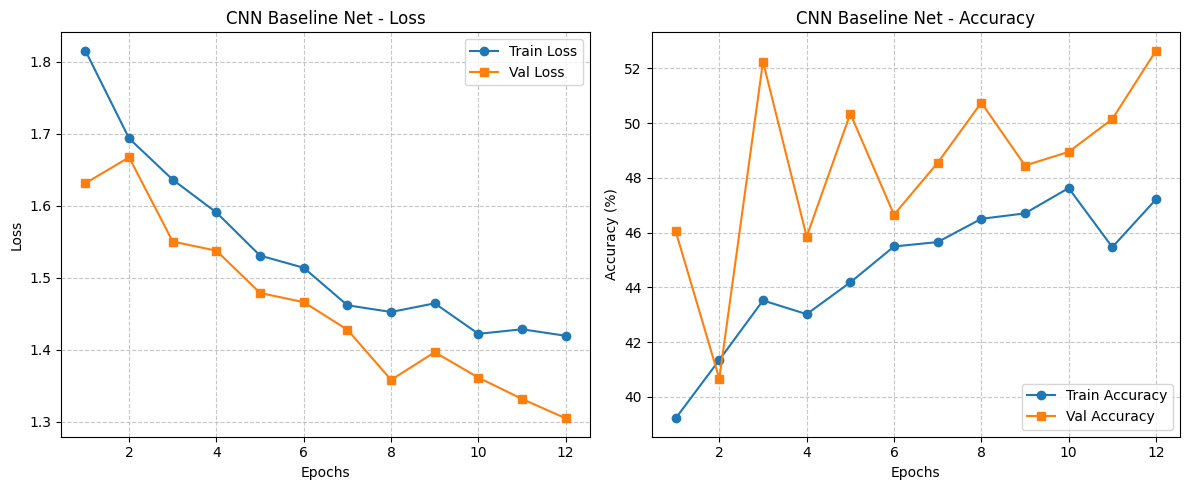

In [16]:
def plot_learning_curves(history, title):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Val Loss', marker='s')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(epochs, history['val_acc'], label='Val Accuracy', marker='s')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig("results/baseline_curves.png")

    plt.show()

# Plots
print("\n--- GRAPHS ---")
plot_learning_curves(history_bn, "CNN Baseline Net")